In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"C:\Users\yuvar\Downloads\heart.csv")

In [3]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
data_dup = data.duplicated().any()

In [5]:
data_dup

True

In [6]:
data = data.drop_duplicates()

In [7]:
data_dup = data.duplicated().any()

In [8]:
data_dup

False

In [9]:
categorical_val = []                       #'''cate'''
numerical_val = []                         #'''cont'''
for column in data.columns:
    if data[column].nunique() <=10:
        categorical_val.append(column)
    else:
        numerical_val.append(column)

In [10]:
categorical_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [11]:
numerical_val

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [12]:
 cate_val=categorical_val
cont_val=numerical_val

In [13]:
categorical_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [14]:
data['cp'].unique()

array([0, 1, 2, 3], dtype=int64)

In [15]:
cate_val.remove('sex')
cate_val.remove('target')
data = pd.get_dummies(data,columns = cate_val,drop_first=True)
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [16]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
st = StandardScaler()
data[cont_val] = st.fit_transform(data[cont_val])

In [19]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,-0.037124,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,1,0.478910,-0.841918,0.237495,1.773958,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,1,0.764066,-1.403197,-1.074521,1.342748,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,1,0.935159,-0.841918,0.499898,-0.899544,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0,0.364848,0.919336,-1.905464,0.739054,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [20]:
X = data.drop('target',axis=1)

In [21]:
y = data['target']

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

y_test



245    1
349    0
135    0
389    1
66     1
      ..
402    1
123    1
739    0
274    1
256    1
Name: target, Length: 61, dtype: int64

In [23]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,-0.037124,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,1,0.478910,-0.841918,0.237495,1.773958,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,1,0.764066,-1.403197,-1.074521,1.342748,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,1,0.935159,-0.841918,0.499898,-0.899544,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0,0.364848,0.919336,-1.905464,0.739054,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [26]:
y_pred1 = log.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

In [28]:
accuracy_score(y_test,y_pred1)

0.7868852459016393

In [29]:
from sklearn import svm

In [30]:
svm = svm.SVC()

In [31]:
svm.fit(X_train,y_train)

SVC()

In [32]:

y_pred2 = svm.predict(X_test)

In [33]:
accuracy_score(y_test,y_pred2)

0.8032786885245902

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
knn = KNeighborsClassifier()

In [36]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [37]:
y_pred3=knn.predict(X_test)

In [38]:
accuracy_score(y_test,y_pred3)

0.7377049180327869

In [39]:
score = []

for k in range(1,40):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    score.append(accuracy_score(y_test,y_pred))

In [40]:
import matplotlib.pyplot as plt

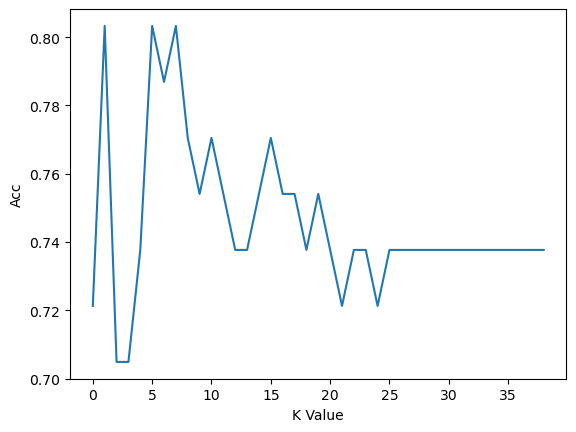

In [41]:
plt.plot(score)
plt.xlabel("K Value")
plt.ylabel("Acc")
plt.show()

In [42]:
knn=KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy_score(y_test,y_pred)

0.8032786885245902

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:

dt = DecisionTreeClassifier()

In [45]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [46]:
y_pred4= dt.predict(X_test)

In [47]:
accuracy_score(y_test,y_pred4)


0.7540983606557377

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
rf = RandomForestClassifier()

In [50]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [51]:

y_pred5= rf.predict(X_test)

In [52]:
accuracy_score(y_test,y_pred5)

0.8032786885245902

In [53]:
final_data = pd.DataFrame({'Models':['LR','SVM','KNN','DT','RF'],
                          'ACC':[accuracy_score(y_test,y_pred1)*100,
                                accuracy_score(y_test,y_pred2)*100,
                                accuracy_score(y_test,y_pred3)*100,
                                accuracy_score(y_test,y_pred4)*100,
                                accuracy_score(y_test,y_pred5)*100,]})

In [54]:
final_data

,Models,ACC
0,LR,78.688525
1,SVM,80.327869
2,KNN,73.770492
3,DT,75.409836
4,RF,80.327869


In [55]:
import seaborn as sns

<Axes: xlabel='Models', ylabel='ACC'>

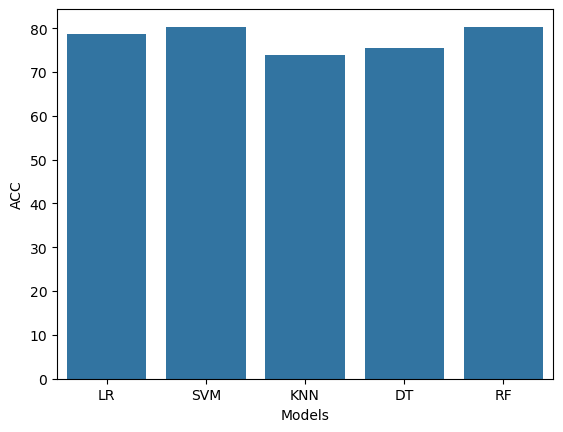

In [56]:
sns.barplot(x=final_data['Models'], y=final_data['ACC'])


In [57]:
X=data.drop('target',axis=1)
y=data['target']

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf = RandomForestClassifier()
rf.fit(X, y)


RandomForestClassifier()

In [60]:
import pickle

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(st, f)

# Save column names after encoding
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)


In [61]:
import pickle

# Save Logistic Regression
with open("log_model.pkl", "wb") as f:
    pickle.dump(log, f)

# Save SVM
with open("svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)

# Save KNN
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

# Save Decision Tree
with open("dt_model.pkl", "wb") as f:
    pickle.dump(dt, f)

# Save Random Forest
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)



print("All models saved successfully!")


All models saved successfully!


In [62]:
import pickle
import pandas as pd

# Load model, scaler, and columns
rf = pickle.load(open("random_forest_model.pkl", "rb"))

scaler = pickle.load(open("scaler.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

new_data = pd.DataFrame([{ ... }])  # your data

# One-hot encode
new_data = pd.get_dummies(new_data)

# Reindex to match training columns
new_data = new_data.reindex(columns=columns, fill_value=0)

# Scale numerical columns
num_cols = ['age','trestbps','chol','thalach','oldpeak']  # same as cont_val
new_data[num_cols] = scaler.transform(new_data[num_cols])

# Predict
result = rf.predict(new_data)
print("Prediction:", result)




Prediction: [1]


In [63]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import time

# =========================
# Load Saved Objects
# =========================
# Adjust paths if needed
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("columns.pkl", "rb") as f:
    model_columns = pickle.load(f)

with open("random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("knn_model.pkl", "rb") as f:
    knn_model = pickle.load(f)

with open("dt_model.pkl", "rb") as f:
    dt_model = pickle.load(f)

# Numerical columns (same as cont_val in training)
NUM_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Base feature names before encoding
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

# =========================
# Streamlit Page Config & CSS
# =========================
st.set_page_config(
    page_title="Heart Disease Predictor",
    page_icon="❤️",
    layout="wide"
)

st.markdown("""
    <style>
        .stApp {
            background: linear-gradient(135deg, #f5f7fa 0%, #e8eaed 100%);
            font-family: 'Helvetica Neue', Arial, sans-serif;
        }

        h1 {
            color: #2c3e50 !important;
            font-weight: 700;
            text-align: center;
            margin-bottom: 0.5rem;
            padding-bottom: 0.5rem;
            border-bottom: 2px solid #e74c3c;
        }

        .subtitle {
            text-align: center;
            color: #34495e !important;
            font-size: 1.2rem;
            margin-bottom: 2rem;
        }

        /* Sidebar */
        [data-testid="stSidebar"] {
            background-color: #2c3e50;
        }

        [data-testid="stSidebar"] h2 {
            color: #ecf0f1 !important;
            font-size: 1.5rem;
            border-bottom: 1px solid #e74c3c;
            padding-bottom: 0.7rem;
            margin-bottom: 1.5rem;
        }

        [data-testid="stSidebar"] .stRadio label,
        [data-testid="stSidebar"] .stSlider label,
        [data-testid="stSidebar"] .stSelectbox label,
        [data-testid="stSidebar"] .stExpander div,
        [data-testid="stSidebar"] p,
        [data-testid="stSidebar"] span {
            color: #ecf0f1 !important;
        }

        [data-testid="stSidebar"] select,
        [data-testid="stSidebar"] .stSelectbox div[data-baseweb="select"] div[role="button"] {
            color: #2c3e50 !important;
        }

        /* General cards */
        .card {
            background-color: white;
            border-radius: 8px;
            padding: 1.5rem;
            box-shadow: 0 4px 6px rgba(0,0,0,0.1);
            margin-bottom: 1.5rem;
            border-left: 4px solid #3498db;
        }

        .risk-meter {
            height: 8px;
            background-color: #eee;
            border-radius: 4px;
            margin-bottom: 5px;
            overflow: hidden;
        }

        .risk-meter-fill {
            height: 100%;
            border-radius: 4px;
        }

        div.stButton > button {
            background-color: #e74c3c;
            color: white !important;
            font-weight: 600;
            border: none;
            border-radius: 6px;
            padding: 0.6rem 1.2rem;
            box-shadow: 0 2px 5px rgba(0,0,0,0.15);
            transition: all 0.3s ease;
        }

        div.stButton > button:hover {
            background-color: #c0392b;
            box-shadow: 0 4px 8px rgba(0,0,0,0.2);
            transform: translateY(-2px);
        }

        .stProgress > div > div > div {
            background-color: #e74c3c;
        }
    </style>
""", unsafe_allow_html=True)

# =========================
# Title
# =========================
st.markdown("<h1>Heart Disease Risk Assessment</h1>", unsafe_allow_html=True)
st.markdown(
    '<p class="subtitle">Advanced AI-powered clinical decision support tool</p>',
    unsafe_allow_html=True
)

col1, col2 = st.columns([1, 2])

# =========================
# Sidebar Inputs
# =========================
with st.sidebar:
    st.markdown("<h2>Patient Information</h2>", unsafe_allow_html=True)

    with st.expander("Demographics", expanded=True):
        age = st.slider("Age", 20, 100, 50)
        sex = st.radio("Sex", options=["Male", "Female"])
        sex_numeric = 1 if sex == "Male" else 0

    with st.expander("Clinical Measurements", expanded=True):
        trestbps = st.slider("Resting Blood Pressure (mm Hg)", 80, 200, 120)
        chol = st.slider("Cholesterol (mg/dl)", 100, 600, 250)
        fbs = st.radio("Fasting Blood Sugar > 120 mg/dl", ["No", "Yes"])
        fbs_numeric = 1 if fbs == "Yes" else 0
        thalach = st.slider("Maximum Heart Rate", 70, 220, 150)

    with st.expander("Cardiac Assessment", expanded=True):
        cp_options = {
            0: "Typical Angina",
            1: "Atypical Angina",
            2: "Non-anginal Pain",
            3: "Asymptomatic"
        }
        cp = st.selectbox(
            "Chest Pain Type",
            options=list(cp_options.keys()),
            format_func=lambda x: cp_options[x]
        )

        restecg_options = {
            0: "Normal",
            1: "ST-T Wave Abnormality",
            2: "Left Ventricular Hypertrophy"
        }
        restecg = st.selectbox(
            "Resting ECG",
            options=list(restecg_options.keys()),
            format_func=lambda x: restecg_options[x]
        )

        exang = st.radio("Exercise Induced Angina", ["No", "Yes"])
        exang_numeric = 1 if exang == "Yes" else 0

        oldpeak = st.slider("ST Depression Induced by Exercise", 0.0, 6.2, 1.0, 0.1)

        slope_options = {
            0: "Upsloping",
            1: "Flat",
            2: "Downsloping"
        }
        slope = st.selectbox(
            "Slope of Peak Exercise ST Segment",
            options=list(slope_options.keys()),
            format_func=lambda x: slope_options[x]
        )

    with st.expander("Advanced Indicators", expanded=True):
        ca = st.slider("Number of Major Vessels (0-4)", 0, 4, 1)

        thal_options = {
            0: "Normal",
            1: "Fixed Defect",
            2: "Reversible Defect",
            3: "Unknown"
        }
        thal = st.selectbox(
            "Thalassemia",
            options=list(thal_options.keys()),
            format_func=lambda x: thal_options[x]
        )

# Create raw input DataFrame (before encoding)
user_data = {
    "age": age,
    "sex": sex_numeric,
    "cp": cp,
    "trestbps": trestbps,
    "chol": chol,
    "fbs": fbs_numeric,
    "restecg": restecg,
    "thalach": thalach,
    "exang": exang_numeric,
    "oldpeak": oldpeak,
    "slope": slope,
    "ca": ca,
    "thal": thal
}
user_input = pd.DataFrame(user_data, index=[0])

# =========================
# Left Column: Overview & Risk Meters
# =========================
with col1:
    st.markdown("<h3>Patient Overview</h3>", unsafe_allow_html=True)

    st.markdown(f"""
    <div style="background-color: white; border-radius: 8px; padding: 15px;
                box-shadow: 0 2px 5px rgba(0,0,0,0.1); margin-bottom: 20px;
                border-left: 4px solid #3498db;">
        <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
            <div><strong>Age:</strong> {age}</div>
            <div><strong>Sex:</strong> {sex}</div>
        </div>
        <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
            <div><strong>BP:</strong> {trestbps} mmHg</div>
            <div><strong>Cholesterol:</strong> {chol} mg/dl</div>
        </div>
        <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
            <div><strong>Max HR:</strong> {thalach} bpm</div>
            <div><strong>Chest Pain:</strong> {cp_options[cp]}</div>
        </div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("<h3>Key Risk Indicators</h3>", unsafe_allow_html=True)

    def risk_level(val, feature):
        if feature == "chol":
            if val < 200:
                return "Low", "2ecc71"
            elif val < 240:
                return "Moderate", "f39c12"
            else:
                return "High", "e74c3c"
        elif feature == "trestbps":
            if val < 120:
                return "Normal", "2ecc71"
            elif val < 130:
                return "Elevated", "3498db"
            elif val < 140:
                return "Stage 1", "f39c12"
            else:
                return "Stage 2", "e74c3c"
        elif feature == "age":
            if val < 45:
                return "Lower", "2ecc71"
            elif val < 65:
                return "Moderate", "f39c12"
            else:
                return "Higher", "e74c3c"

    col_r1, col_r2, col_r3 = st.columns(3)

    with col_r1:
        chol_level, chol_color = risk_level(chol, "chol")
        st.markdown(f"""
        <div style="text-align: center;">
            <p><strong>Cholesterol</strong></p>
            <div class="risk-meter">
                <div class="risk-meter-fill"
                     style="width: {min(100, max(0, (chol-100)/5))}%; background-color: #{chol_color};">
                </div>
            </div>
            <p style="color: #{chol_color};">{chol_level} ({chol} mg/dl)</p>
        </div>
        """, unsafe_allow_html=True)

    with col_r2:
        bp_level, bp_color = risk_level(trestbps, "trestbps")
        st.markdown(f"""
        <div style="text-align: center;">
            <p><strong>Blood Pressure</strong></p>
            <div class="risk-meter">
                <div class="risk-meter-fill"
                     style="width: {min(100, max(0, (trestbps-80)/1.2))}%; background-color: #{bp_color};">
                </div>
            </div>
            <p style="color: #{bp_color};">{bp_level} ({trestbps} mmHg)</p>
        </div>
        """, unsafe_allow_html=True)

    with col_r3:
        age_level, age_color = risk_level(age, "age")
        st.markdown(f"""
        <div style="text-align: center;">
            <p><strong>Age Risk</strong></p>
            <div class="risk-meter">
                <div class="risk-meter-fill"
                     style="width: {min(100, age)}%; background-color: #{age_color};">
                </div>
            </div>
            <p style="color: #{age_color};">{age_level} ({age} years)</p>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("""
    <div style="background-color: #f8f9fa; border-radius: 8px; padding: 15px; margin: 20px 0;">
        <strong>Additional Factors:</strong>
    """, unsafe_allow_html=True)

    risk_factors = []
    if sex == "Male":
        risk_factors.append("Male gender")
    if fbs == "Yes":
        risk_factors.append("Elevated fasting blood sugar")
    if exang == "Yes":
        risk_factors.append("Exercise-induced angina")
    if cp != 0:
        risk_factors.append(cp_options[cp])
    if ca > 0:
        risk_factors.append(f"{ca} major vessels colored by fluoroscopy")

    if risk_factors:
        for rfct in risk_factors:
            st.markdown(f'<p style="margin: 5px 0 5px 15px;">• {rfct}</p>', unsafe_allow_html=True)
    else:
        st.markdown('<p>No additional significant risk factors identified.</p>', unsafe_allow_html=True)

    st.markdown('</div>', unsafe_allow_html=True)

# =========================
# Right Column: Prediction Logic
# =========================
with col2:
    st.markdown("<h3>Heart Disease Risk Assessment</h3>", unsafe_allow_html=True)

    # ---- Preprocess function that matches training code ----
    def preprocess_for_model(df_raw: pd.DataFrame) -> pd.DataFrame:
        # 1. One-hot encode
        df_enc = pd.get_dummies(df_raw)

        # 2. Align columns with training columns
        df_enc = df_enc.reindex(columns=model_columns, fill_value=0)

        # 3. Scale numerical columns
        df_enc[NUM_COLS] = scaler.transform(df_enc[NUM_COLS])

        return df_enc

    if st.button("Generate Risk Assessment", key="predict_button"):
        with st.spinner("Analyzing patient data..."):
            progress_bar = st.progress(0)
            for i in range(100):
                time.sleep(0.01)
                progress_bar.progress(i + 1)

            X_input = preprocess_for_model(user_input)

            # Predictions + probabilities
            rf_pred = rf_model.predict(X_input)[0]
            rf_proba = rf_model.predict_proba(X_input)[0][1]

            knn_pred = knn_model.predict(X_input)[0]
            knn_proba = knn_model.predict_proba(X_input)[0][1]

            dt_pred = dt_model.predict(X_input)[0]
            dt_proba = dt_model.predict_proba(X_input)[0][1]

            # Ensemble (average probability)
            ensemble_risk = (rf_proba + knn_proba + dt_proba) / 3

            # ---- Overall risk section ----
            st.markdown("<h3>Overall Risk Assessment</h3>", unsafe_allow_html=True)
            risk_level_txt = "Low" if ensemble_risk < 0.4 else "Moderate" if ensemble_risk < 0.7 else "High"
            risk_color = "#2ecc71" if risk_level_txt == "Low" else "#f39c12" if risk_level_txt == "Moderate" else "#e74c3c"

            st.markdown(f"""
            <div style="text-align: center; margin-bottom: 20px;">
                <div style="background-color: white; border-radius: 10px; padding: 20px;
                            box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
                    <h2 style="color: {risk_color}; margin-bottom: 10px;">{risk_level_txt} Risk</h2>
                    <div style="height: 20px; background-color: #eee; border-radius: 10px;
                                margin: 20px 0; position: relative;">
                        <div style="width: {ensemble_risk * 100}%; height: 100%;
                                    background: linear-gradient(90deg, #2ecc71, #f39c12, #e74c3c);
                                    border-radius: 10px;"></div>
                        <div style="width: 10px; height: 30px; background-color: #2c3e50;
                                    border-radius: 5px; position: relative; top: -25px;
                                    left: calc({ensemble_risk * 100}% - 5px);"></div>
                    </div>
                    <p style="font-size: 1.5rem; font-weight: bold; color: #2c3e50;">
                        {ensemble_risk:.1%}
                    </p>
                    <p style="color: #2c3e50;">Probability of Heart Disease</p>
                </div>
            </div>
            """, unsafe_allow_html=True)

            # ---- Individual model cards ----
            st.markdown("<h4>Model Predictions</h4>", unsafe_allow_html=True)
            col_rf, col_knn, col_dt = st.columns(3)

            def show_model_prediction(col, model_name, prediction, probability, icon):
                result_text = "Positive" if prediction == 1 else "Negative"
                result_color = "#e74c3c" if prediction == 1 else "#2ecc71"

                col.markdown(f"""
                <div style="background-color: white; border-radius: 8px; padding: 15px;
                            box-shadow: 0 2px 5px rgba(0,0,0,0.1); margin-bottom: 15px;
                            border-left: 4px solid {result_color}; height: 100%;">
                    <div style="text-align: center; margin-bottom: 10px;">
                        <span style="font-size: 1.5rem;">{icon}</span>
                        <h4 style="margin: 5px 0; color: #2c3e50;">{model_name}</h4>
                    </div>
                    <div style="text-align: center;">
                        <p style="font-size: 1.2rem; font-weight: bold; color: {result_color};">
                            {result_text}
                        </p>
                        <p style="font-size: 0.9rem; color: #2c3e50;">
                            Confidence: {probability:.1%}
                        </p>
                    </div>
                </div>
                """, unsafe_allow_html=True)

            show_model_prediction(col_rf, "Random Forest", rf_pred, rf_proba, "🌲")
            show_model_prediction(col_knn, "K-Nearest Neighbors", knn_pred, knn_proba, "🔗")
            show_model_prediction(col_dt, "Decision Tree", dt_pred, dt_proba, "🌳")

            # ---- Findings & Recommendations ----
            st.markdown("<h4>Key Findings & Recommendations</h4>", unsafe_allow_html=True)

            recommendations = []
            if chol > 200:
                recommendations.append("Monitor cholesterol levels and consider dietary changes.")
            if trestbps >= 130:
                recommendations.append("Follow up on blood pressure management.")
            if age > 65:
                recommendations.append("Regular cardiac check-ups recommended for this age group.")
            if exang == "Yes":
                recommendations.append("Further evaluation of exercise-induced angina is advised.")
            if ca > 0:
                recommendations.append("Follow up with a cardiologist regarding coronary vessel health.")

            recommendations.append("Maintain a heart-healthy diet rich in fruits and vegetables.")
            recommendations.append("Engage in regular physical activity appropriate for your condition.")

            st.markdown("""
            <div style="background-color: #f8f9fa; border-radius: 8px; padding: 15px; margin: 20px 0;">
            """, unsafe_allow_html=True)

            if ensemble_risk > 0.7:
                st.markdown("""
                <p><strong>Clinical Assessment:</strong> Multiple risk factors indicate a high probability of
                coronary artery disease. Immediate follow-up with a cardiologist is strongly recommended.</p>
                """, unsafe_allow_html=True)
            elif ensemble_risk > 0.4:
                st.markdown("""
                <p><strong>Clinical Assessment:</strong> The patient presents moderate risk factors for
                coronary artery disease. Additional diagnostic testing may be warranted.</p>
                """, unsafe_allow_html=True)
            else:
                st.markdown("""
                <p><strong>Clinical Assessment:</strong> The patient currently shows a lower risk profile.
                Preventive measures and routine monitoring are advised.</p>
                """, unsafe_allow_html=True)

            st.markdown('<p><strong>Recommendations:</strong></p>', unsafe_allow_html=True)
            for rec in recommendations[:5]:
                st.markdown(f'<p style="margin: 5px 0 5px 15px;">• {rec}</p>', unsafe_allow_html=True)

            st.markdown('</div>', unsafe_allow_html=True)

            st.markdown("""
            <div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px; margin-top: 20px;">
                <p style="font-size: 0.8rem;">
                <strong>Disclaimer:</strong> This tool is for educational and decision-support purposes only and
                is not a substitute for professional medical diagnosis or treatment.
                </p>
            </div>
            """, unsafe_allow_html=True)

    else:
        # Info when no prediction yet
        st.markdown("""
        <div style="background-color: white; border-radius: 8px; padding: 15px;
                    box-shadow: 0 2px 5px rgba(0,0,0,0.1); margin-bottom: 20px;">
            <h4>About This Tool</h4>
            <p>This clinical decision support system uses machine learning models trained on heart disease data
            to estimate the probability of heart disease.</p>
            <p>Enter patient information in the sidebar and click
            <strong>"Generate Risk Assessment"</strong> to get a detailed analysis.</p>
        </div>
        """, unsafe_allow_html=True)

        st.markdown("<h4>Model Information</h4>", unsafe_allow_html=True)
        model_info = [
            {
                "name": "Random Forest",
                "icon": "🌲",
                "description": "Ensemble of decision trees for robust, high-accuracy predictions."
            },
            {
                "name": "K-Nearest Neighbors",
                "icon": "🔗",
                "description": "Compares the patient to similar historical cases."
            },
            {
                "name": "Decision Tree",
                "icon": "🌳",
                "description": "Transparent, rule-based model similar to clinical decision trees."
            }
        ]

        for m in model_info:
            st.markdown(f"""
            <div style="background-color: #f9f9f9; border-radius: 8px; padding: 15px;
                        margin-bottom: 15px; border-left: 3px solid #3498db;">
                <div style="display: flex; align-items: center;">
                    <span style="font-size: 1.5rem; margin-right: 10px;">{m["icon"]}</span>
                    <div>
                        <h5 style="margin: 0;">{m["name"]}</h5>
                        <p style="margin: 5px 0 0 0; font-size: 0.9rem;">{m["description"]}</p>
                    </div>
                </div>
            </div>
            """, unsafe_allow_html=True)

# =========================
# Footer
# =========================
st.markdown("""
<div style="margin-top: 40px; padding-top: 20px; border-top: 1px solid #e0e0e0; text-align: center;">
    <p style="color: #7f8c8d; font-size: 0.9rem;">© 2025 Heart Disease Risk Assessment Tool</p>
    <p style="color: #7f8c8d; font-size: 0.9rem;">Clinical decision support powered by machine learning</p>
</div>
""", unsafe_allow_html=True)


2026-06-15 12:33:20.245 
  command:

    streamlit run c:\Users\yuvar\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-15 12:33:20.247 Session state does not function when running a script without `streamlit run`


DeltaGenerator()

In [64]:
from sklearn.preprocessing import StandardScaler

st = StandardScaler()
data[cont_val] = st.fit_transform(data[cont_val])


In [65]:
cd C:\Users\yuvar\Documents\Heart_Attack_Predictor


[WinError 2] The system cannot find the file specified: 'C:\\Users\\yuvar\\Documents\\Heart_Attack_Predictor'
c:\Users\yuvar\Heart_App


In [66]:
# Train models again
log = LogisticRegression().fit(X_train, y_train)
svm = svm.SVC(probability=True).fit(X_train, y_train)
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)


AttributeError: 'SVC' object has no attribute 'SVC'

In [ ]:
import pickle

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(st, f)

# Save columns after encoding
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# Save models
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

with open("dt_model.pkl", "wb") as f:
    pickle.dump(dt, f)


In [ ]:
import pickle

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Scaler loaded!")


Scaler loaded!


In [ ]:
streamlit run heart_app.py


SyntaxError: invalid syntax (782875685.py, line 1)

In [ ]:
from sklearn.svm import SVC

svc = SVC(probability=True)
svc.fit(X_train, y_train)


SVC(probability=True)

In [ ]:
pickle.dump(svc, open("svm_model.pkl", "wb"))
